# Знакомство с рекуррентными нейронными сетями. Архитектуры LSTM и GRU (V2)

## Введение

В основе классических архитектур нейронных сетей, таких как многослойные перцептроны (MLP), лежит предположение о независимости входных данных. Каждый входной пример обрабатывается изолированно, без учета его связи с предыдущими или последующими примерами.

Этот подход эффективен для множества задач, однако он оказывается нецелесообразен к применению при работе с последовательными данными (текст, речь, временные ряды). Здесь порядок элементов имеет решающее значение: изменение порядка слов в предложении может кардинально изменить его смысл.

Рекуррентные нейронные сети (Recurrent Neural Networks, RNN) разработаны для решения этой проблемы. Rлючевая особенность — наличие внутреннего состояния ("памяти"), которое передаётся от одного временного шага к другому. На каждом шаге обработки элемента последовательности (например, "токена") сеть принимает на вход не только сам элемент, но и своё состояние с предыдущего шага.

Это позволяет сети накапливать информацию о предшествующем контексте и использовать её при интерпретации текущего элемента.



> RNN не просто модель для статического отображения входа на выход, $y = f(x)$. Она обучается **моделировать динамическую систему**, $(h_t, y_t) = f(x_t, h_{t-1})$, где $h_t$ — состояние системы в момент времени $t$. 


## Сеть Элмана

Простейшая и наиболее распространенная архитектура РНС — **сеть Элмана**. Ячейку можно представить как блок, который получает на вход текущий элемент последовательности $x_t$ и скрытое состояние с предыдущего шага $h_{t-1}$, а на выходе производит обновлённое скрытое состояние $h_t$ и, возможно, выход $y_t$.

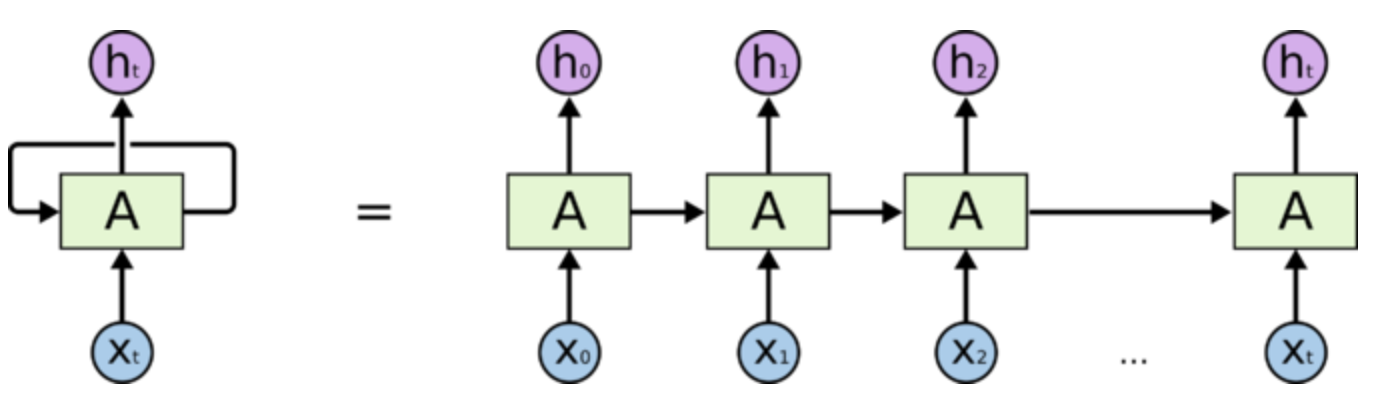


Для понимания процесса обучения и работы сети её "разворачивают" во времени. Развернутая сеть представляет собой глубокую нейронную сеть, где каждый временной шаг становится отдельным слоем. Важнейшей особенностью является то, что веса на всех этих "слоях" (временных шагах) являются общими.

### Вычисление скрытого состояния

$$ h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b_h) $$

*   $h_t \in \mathbb{R}^{d_h}$ — вектор скрытого состояния в момент времени $t$, где $d_h$ — размерность скрытого слоя
*   $h_{t-1} \in \mathbb{R}^{d_h}$ — вектор скрытого состояния с предыдущего шага
*   $x_t \in \mathbb{R}^{d_x}$ — входной вектор в момент времени $t$, где $d_x$ — размерность входа (эмбеддинга токена)
*   $W_{hh} \in \mathbb{R}^{d_h \times d_h}$ — матрица весов для рекуррентного соединения (от $h_{t-1}$ к $h_t$)
*   $W_{xh} \in \mathbb{R}^{d_h \times d_x}$ — матрица весов для входного соединения (от $x_t$ к $h_t$)
*   $b_h \in \mathbb{R}^{d_h}$ — вектор смещения (`bias`) для скрытого слоя
*   [`tanh`](https://ru.wikipedia.org/wiki/%D0%93%D0%B8%D0%BF%D0%B5%D1%80%D0%B1%D0%BE%D0%BB%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D1%84%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D0%B8) — функция активации (гиперболический тангенс), которая ограничивает значения скрытого состояния диапазоном от -1 до 1


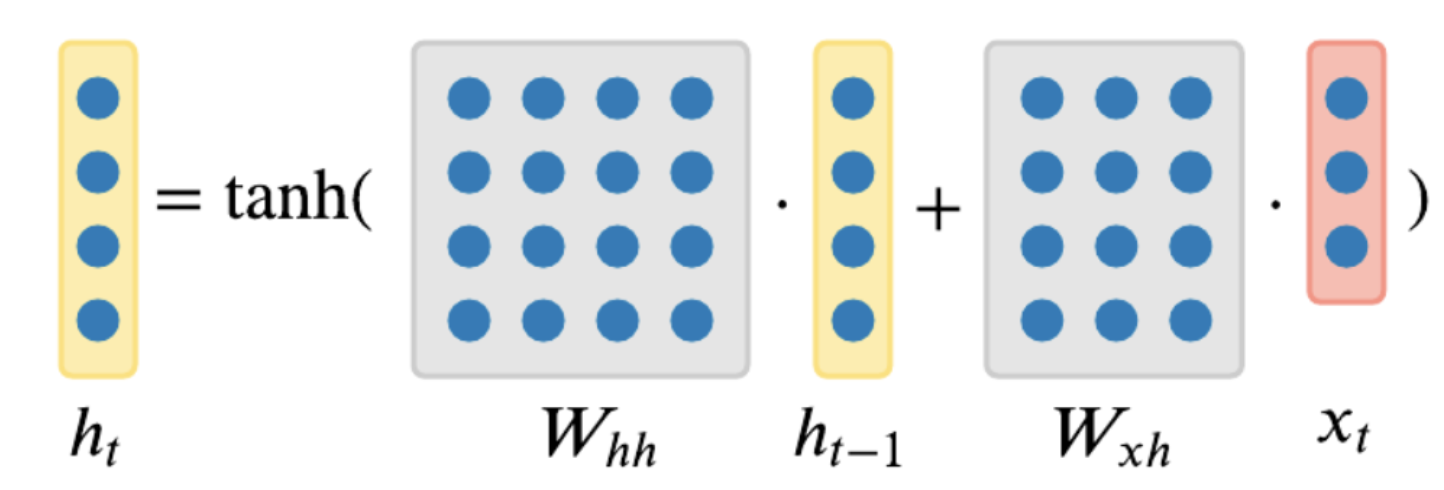

### Вычисление выхода

$$ y_t = W_{hy}h_t + b_y $$

*   $y_t \in \mathbb{R}^{d_y}$ — выходной вектор в момент времени $t$, где $d_y$ — размерность выхода
*  $W_{hy} \in \mathbb{R}^{d_y \times d_h}$ — матрица весов для выходного слоя
*   $b_y \in \mathbb{R}^{d_y}$ — вектор смещения для выходного слоя


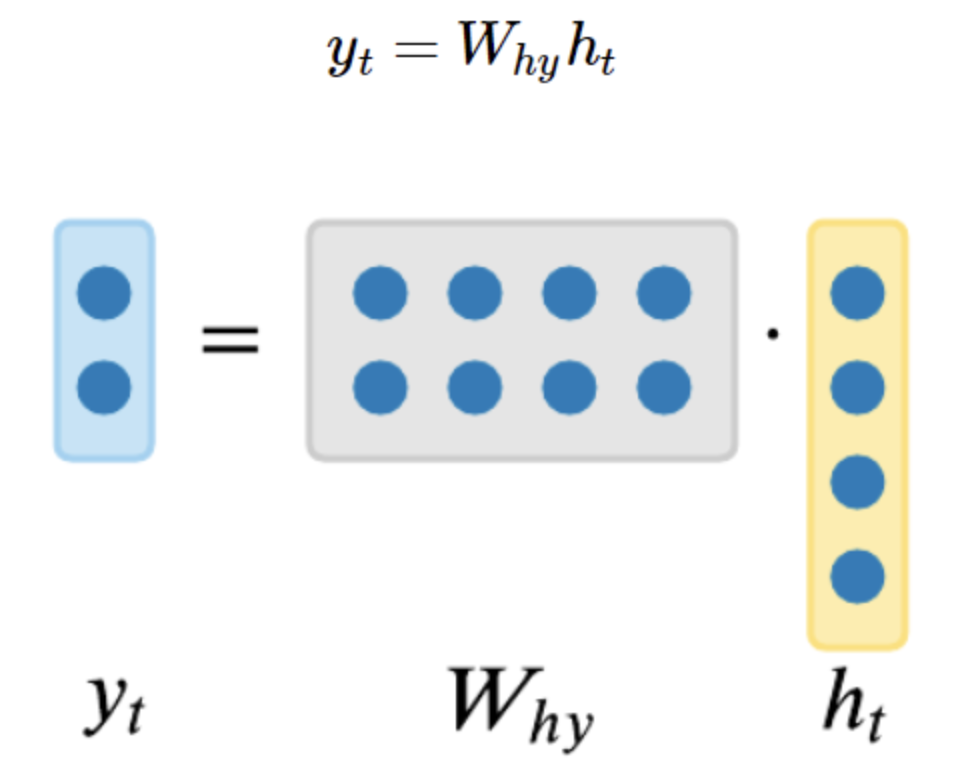

> Использование общих весов на всех временных шагах является одновременно и главной силой, и основной слабостью простой RNN

С одной стороны, это позволяет модели обобщаться на последовательности произвольной длины, изучая универсальное правило обновления состояния. Без общих весов модель могла бы работать только с последовательностями фиксированной длины и не смогла бы выучить общую динамику процесса. С другой стороны, именно это свойство является причиной проблемы нестабильности градиентов.

Особого внимания заслуживают **двунаправленные RNN** (Bidirectional RNNs, BiRNN). Состоят из двух независимых RNN: одна обрабатывает последовательность в прямом порядке (от начала к концу), вторая — в обратном. Это позволяет модели учитывать не только прошлый, но и будущий контекст, что критически важно для таких задач, как определение частей речи или распознавание именованных сущностей.

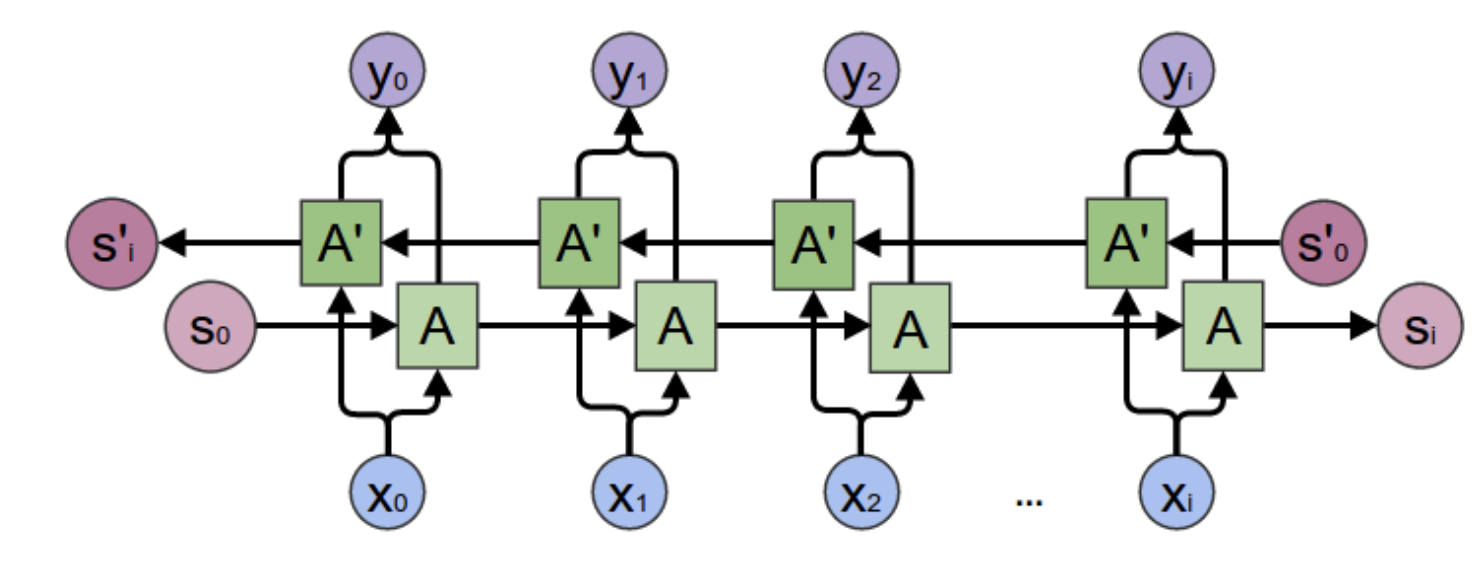


Виды рекуррентных нейронных сетей:

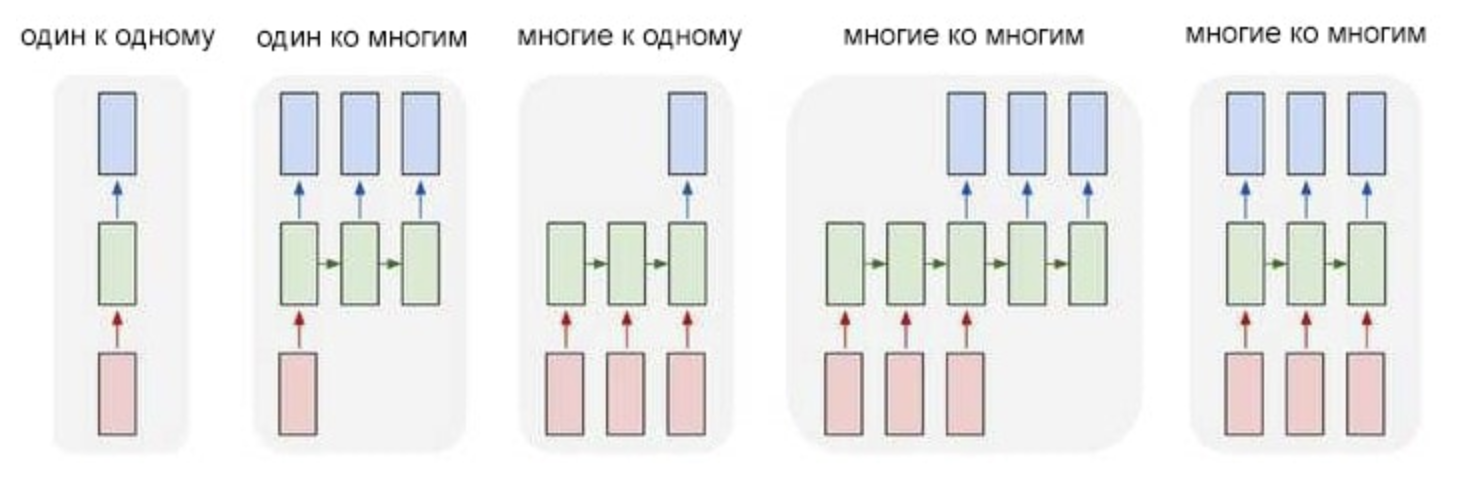

| Тип                                               | Вход                     | Выход                                | Пример задачи                          | Архитектура                     |
|---------------------------------------------------|--------------------------|--------------------------------------|----------------------------------------|----------------------------------|
| **Один к одному** (One-to-One)                   | 1 элемент                | 1 элемент                            | Классификация изображений             | MLP                             |
| **Многие к одному** (Many-to-One)                | Последовательность       | 1 элемент                            | Тональность текста                    | LSTM, GRU, BERT (Encoder-only)  |
| **Один ко многим** (One-to-Many)                 | 1 элемент                | Последовательность                   | Генерация описания к картинке         | RNN Decoder, GPT (Decoder-only) |
| **Многие ко многим** (с выравниванием)           | Последовательность       | Последовательность (той же длины)    | POS-tagging, NER                      | BiLSTM + CRF, BERT              |
| **Многие ко многим** (без выравнивания)          | Последовательность       | Последовательность (другой длины)    | Машинный перевод, суммаризация        | Seq2Seq, T5, BART               |

## Проблемы долгосрочных зависимостей

### Алгоритм Backpropagation Through Time (BPTT)



Обучение RNN производится с помощью алгоритма обратного распространения ошибки во времени. Это стандартный алгоритм backpropagation, применяемый к развёрнутой во времени сети. Процесс выглядит следующим образом:
1.  сеть "разворачивается" на всю длину последовательности $T$
2.  выполняется прямой проход: начиная с $h_0$, последовательно вычисляются все $h_t$ и $y_t$ до конца последовательности
3.  вычисляется функция потерь $L$, обычно как сумма потерь на каждом временном шаге $L = \sum_{t=1}^T L_t$
4.  выполняется обратный проход: градиенты распространяются от конца развернутой сети к её началу
5.  градиенты для общих весов ($W_{hh}, W_{xh}, b_h$) суммируются со всех временных шагов, где эти веса использовались
6.  веса обновляются с помощью градиентного спуска

> В ходе обратного прохода возникает проблема, препятствующая обучению RNN на длинных последовательностях (проблема исчезающих и взрывающихся градиентов)


При вычислении градиента функции потерь $L_t$ по отношению к скрытому состоянию на некотором предыдущем шаге $h_k$ (где $k < t$), по цепному правилу получаем произведение:

$$ \frac{\partial L_t}{\partial h_k} = \frac{\partial L_t}{\partial h_t} \frac{\partial h_t}{\partial h_{t-1}} \frac{\partial h_{t-1}}{\partial h_{t-2}} \cdots \frac{\partial h_{k+1}}{\partial h_k} = \frac{\partial L_t}{\partial h_t} \prod_{i=k+1}^t \frac{\partial h_i}{\partial h_{i-1}} $$

Каждый член $\frac{\partial h_i}{\partial h_{i-1}}$ в этом произведении равен $\tanh'(\cdot) \cdot W_{hh}^T$. Градиент зависит от многократного умножения матрицы весов $W_{hh}$ на саму себя. Если сингулярные значения этой матрицы (квадратные корни из собственных чисел симметричной матрицы $A^T{A}$) больше 1, норма градиента будет расти экспоненциально. Если они меньше 1, градиент будет экспоненциально затухать.

Кроме того производная гиперболического тангенса всегда меньше 1 (что будет приводить к затуханию градиентов):

$$
\frac{d}{dx}\tanh(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2}
$$

$$
= 1 - \frac{(e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \tanh^2(x)
$$

Таким образом:

*   **Исчезающий градиент (Vanishing Gradient):** градиенты от далёких по времени событий становятся пренебрежимо малыми к моменту, когда они достигают начала последовательности; сеть неспособна уловить связь между событиями, разделёнными большим временным лагом, не может обучиться долгосрочным зависимостям
*   **Взрывающийся градиент (Exploding Gradient):** градиенты становятся аномально большими, что приводит к резким, нестабильным обновлениям весов; процесс обучения расходится: функция потерь может принимать значения $\mathrm{NaN}$; наиболее распространённый метод борьбы — *обрезка градиентов (Gradient Clipping)*, который заключается в масштабировании градиентов, если их норма превышает определенный порог

Для снижения вычислительной нагрузки и частичного смягчения проблем градиентов на практике часто используется **усеченный BPTT (Truncated BPTT)**, где обратное распространение ошибки ограничивается лишь несколькими последними временными шагами.


## Продвинутые архитектуры RNN

### Long-Short Term Memory (LSTM)

Для борьбы с проблемой исчезающего градиента в 1997 году Sepp Hochreiter и Jürgen Schmidhuber [предложили новую архитектуру](https://www.bioinf.jku.at/publications/older/2604.pdf).

> Чтобы градиент не затухал при обратном распространении во времени, авторы предложили создать внутри ячейки путь, по которому **ошибка может проходить без изменений** (Constant Error Carousel, CEC)


LSTM-ячейка была дополнена механизмом вентилей (gates), которые представляют собой небольшие нейронные сети с сигмоидной активацией. Сигмоида выдает значения в диапазоне от 0 до 1, которые используются для поэлементного умножения, позволяя контролировать поток информации: 0 означает "полностью заблокировать", 1 — "полностью пропустить".


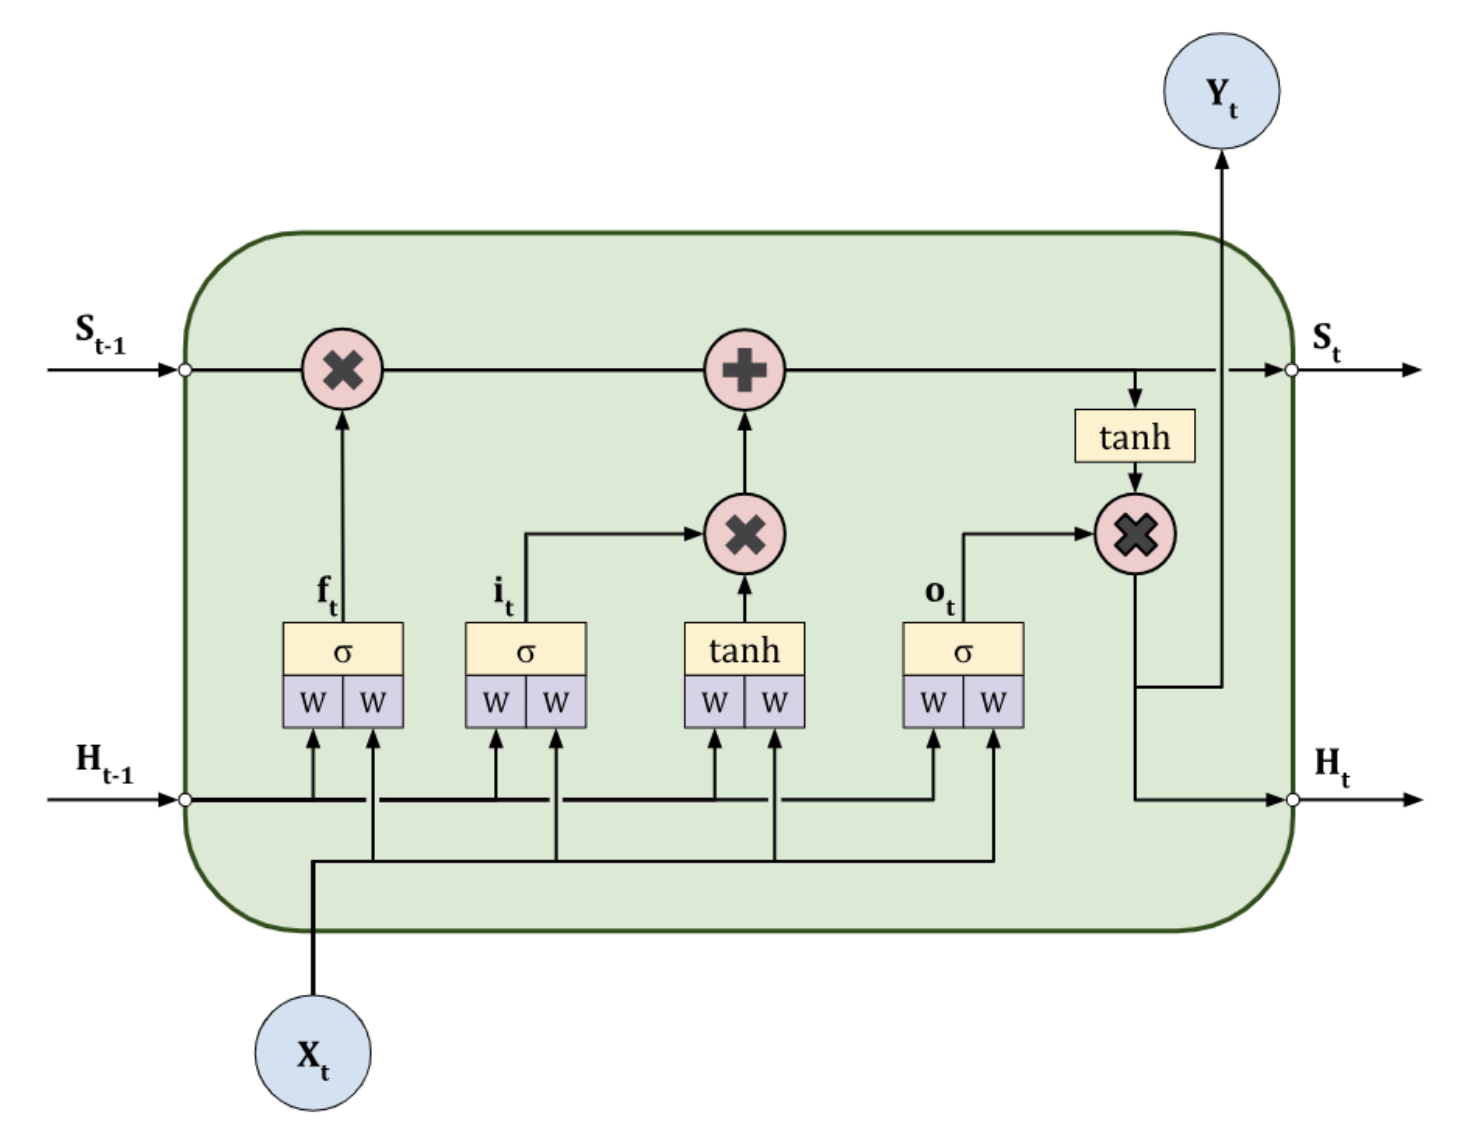

Архитектура LSTM разделяет "память" на два ключевых компонента:

**Состояние ячейки** (Cell State, S): "информационная магистраль" или "конвейер", реализующий идею CEC. Вектор несет информацию сквозь всю последовательность, и его изменения носят в основном аддитивный характер, что защищает от исчезновения градиентов; долгосрочная память

**Скрытое состояние** (Hidden State, H): "рабочая" или краткосрочная память; используется для вычисления выхода на текущем шаге и для управления вентилями на следующем

**Формулы:**

**Вентиль забывания (Forget Gate, $f_t$)**: решает, какую информацию из предыдущего состояния ячейки $S_{t-1}$ следует отбросить

$$f_t = \sigma(W_f \cdot [H_{t-1}, x_t] + b_f)$$

**Вентиль входа (Input Gate, $i_t$) и кандидат на добавление ($\tilde{S}_t$)**: определяют, какая новая информация будет сохранена в состоянии ячейки

$$i_t = \sigma(W_i \cdot [H_{t-1}, x_t] + b_i)$$

$$\tilde{S}_t = \tanh(W_S \cdot [H_{t-1}, x_t] + b_S)$$

**Обновление состояния ячейки (Cell State Update)**: старое состояние $S_{t-1}$ умножается на вентиль забывания $f_t$, а к результату прибавляется новая информация $i_t \odot \tilde{S}_t$

$$S_t = f_t \odot S_{t-1} + i_t \odot \tilde{S}_t$$

Здесь $\odot$ обозначает поэлементное умножение (произведение Адамара)

**Вентиль выхода (Output Gate, $o_t$) и скрытое состояние ($H_t$)**: определяют, какая часть состояния ячейки будет передана на выход в виде скрытого состояния $H_t$

$$o_t = \sigma(W_o \cdot [H_{t-1}, x_t] + b_o)$$

$$H_t = o_t \odot \tanh(S_t)$$

Здесь $[h_{t-1}, x_t]$ обозначает конкатенацию векторов.


### Gated Recurrent Unit (GRU)

В 2014 году Junyoung Chung, Caglar Gulcehre, Kyunghyun Cho и Yoshua Bengio [представили облегчённую версию LSTM](https://arxiv.org/abs/1412.3555), которая демонстрирует сопоставимую производительность, при этом является более вычислительно эффективной и требует меньше параметров.

**Основные изменения:**

- отсутствие состояния ячейки: GRU не имеет отдельного вектора состояния ячейки; его функции выполняет само скрытое состояние $h$
- два вентиля вместо трех: вентили забывания и входа объединены в один вентиль обновления (update gate); также вводится новый вентиль сброса (reset gate)

> Связывание операций забывания и добавления новой информации через единый вентиль обновления действует как форма регуляризации. Модель не может одновременно "сильно забывать" старое и "сильно добавлять" новое


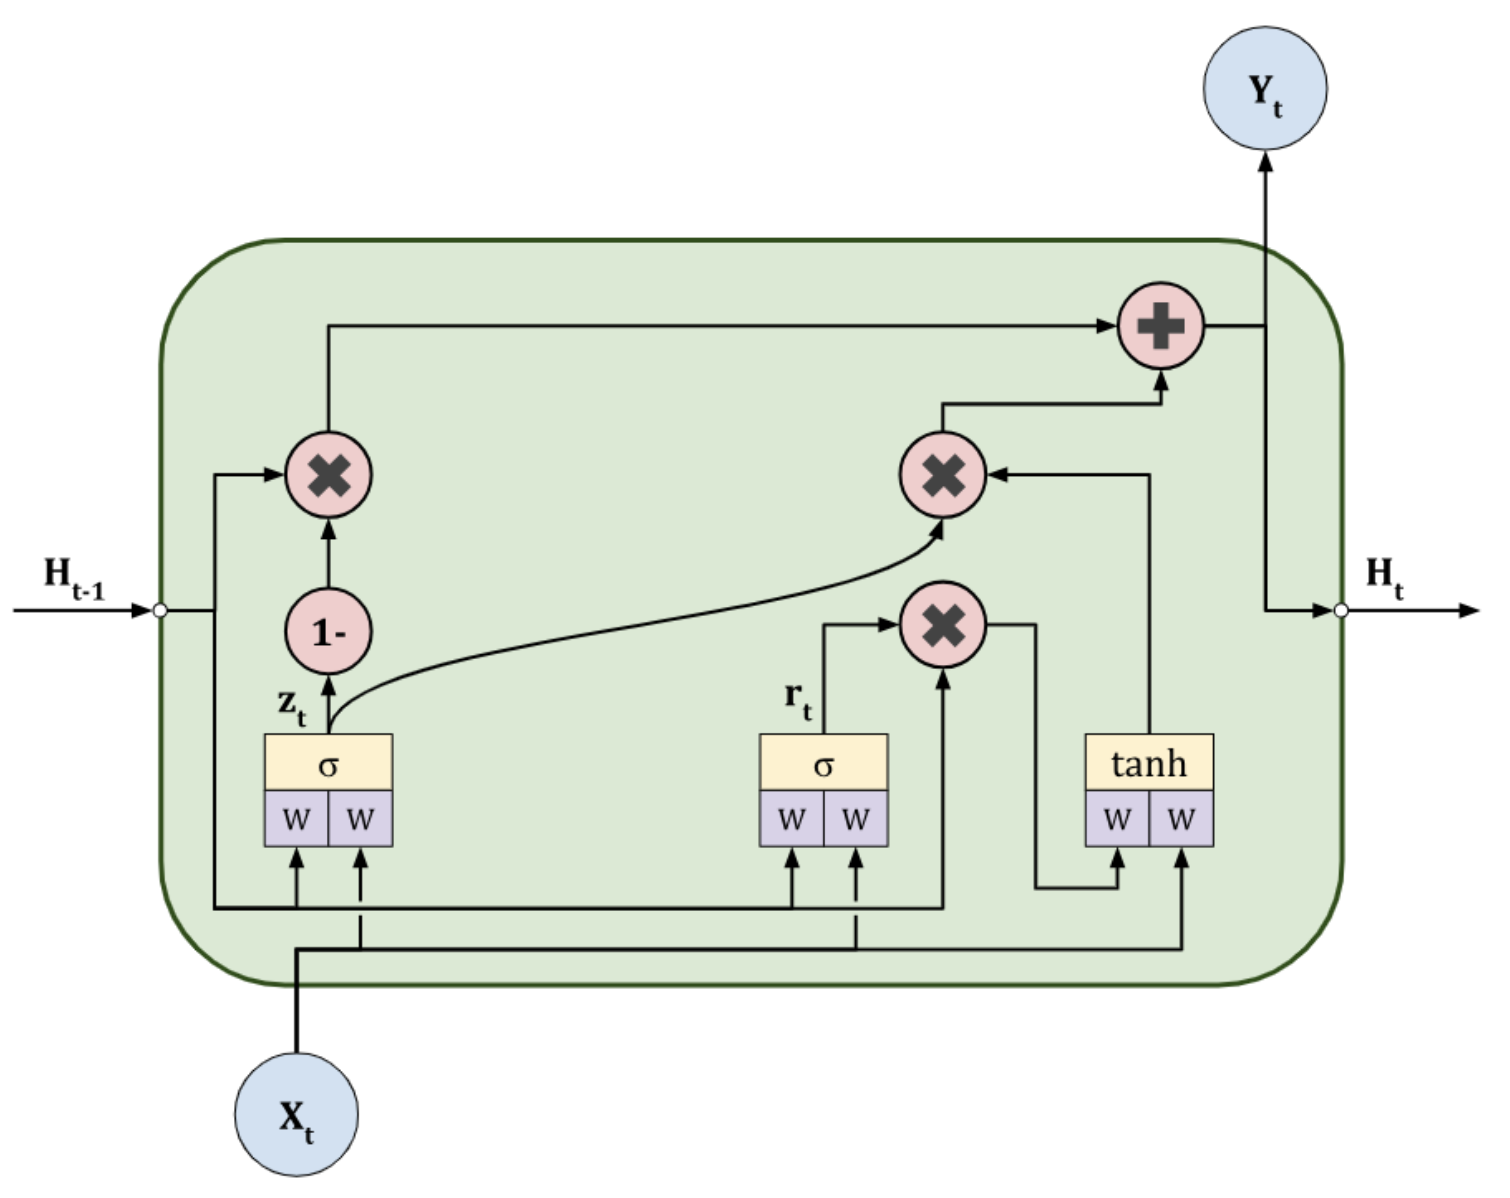

**Формулы:**

**Вентиль сброса (Reset Gate, $r_t$)**: определяет, какую часть информации из прошлого ($H_{t-1}$) следует игнорировать при вычислении нового состояния

$$r_t = \sigma(W_r \cdot [H_{t-1}, x_t] + b_r)$$

**Вентиль обновления (Update Gate, $z_t$)**: определяет, какую долю информации из прошлого состояния $H_{t-1}$ следует сохранить, а какую — заменить новым состоянием

$$z_t = \sigma(W_z \cdot [H_{t-1}, x_t] + b_z)$$

**Кандидатное скрытое состояние ($\tilde{H}_t$)**: содержит информацию из текущего входа и отфильтрованную информацию из прошлого

$$\tilde{H}_t = \tanh(W_h \cdot [r_t \odot H_{t-1}, x_t] + b_H)$$

**Итоговое скрытое состояние ($H_t$)**:

$$H_t = (1 - z_t) \odot H_{t-1} + z_t \odot \tilde{H}_t$$


### Сравнение LSTM и GRU

LSTM имеет более сложную структуру с тремя вентилями и отдельным состоянием ячейки, что дает больше гибкости и контроля над потоком информации; GRU проще, с двумя вентилями и без состояния ячейки.

GRU имеет меньше обучаемых параметров; это приводит к более быстрому обучению и может снизить риск переобучения на небольших наборах данных. 

Во многих задачах производительность GRU и LSTM сопоставима.

> **Рекомендуется начинать с GRU** из-за ее эффективности и переходить к LSTM только если есть основания полагать, что ее дополнительная сложность принесёт значимое улучшение качества для конкретной задачи


## Задача классификации текстовых данных

Задача классификации текста заключается в присвоении тексту одной из предопределенных меток ("позитивный", "негативный", "нейтральный" для анализа тональности; "спорт", "политика", "культура" для тематической классификации). 

С помощью RNN задача решается путём обработки последовательности слов (или токенов) и получения **единого векторного представления текста**, который далее используется для классификации.

**Элементы архитектуры модели:**

**Слой встраивания (Embedding Layer):** преобразует числовые индексы токенов в плотные векторы фиксированной размерности (эмбеддинги); они могут быть обучены с нуля вместе с остальной моделью или инициализированы предварительно обученными векторами (Word2Vec, GloVe, FastText, Navec).

**Рекуррентный слой (LSTM/GRU Layer):** обрабатывает последовательность эмбеддингов, формирует итоговое состояние сети после обработки всей последовательности; используется последний скрытый вектор $h_T$.

**Полносвязный слой (Dense/Fully Connected Layer):** принимает на вход последний скрытый вектор $h_T$ и преобразует его в вектор, размерность которого равна количеству классов.

**Выходной слой (Output Layer):** применяет функцию активации (`Softmax`, `Sigmoid`) к выходу полносвязного слоя для получения итоговых вероятностей.



### torch.nn.RNN

Реализует сеть Элмана.   

**Основные параметры:**
- `input_size`: размерность вектора для одного элемента последовательности (размер эмбеддинга)
- `hidden_size`: Размерность скрытого состояния
- `num_layers`: Количество рекуррентных слоев для создания стековой RNN
- `batch_first=True`: указывает, что тензоры будут иметь формат `(batch, seq_len, features)`, а не `(seq_len, batch, features)` по умолчанию

> Обратите внимание на этот параметр при выполнении ЛР и дополнительных заданий
{.is-warning}

- `bidirectional=True`: позволяет сделать сеть двунаправленной

**Входы:**
- `input`: тензор с данными
- `h_0`: начальное скрытое состояние

**Выходы:**
- `output`: скрытые состояния со всех временных шагов последнего слоя
- `h_n`: финальное скрытое состояние для каждого слоя


### torch.nn.LSTM

Реализует LSTM. Основные параметры аналогичны `torch.nn.RNN`.

**Входы:**
`input`, кортеж `(h_0, c_0)` (начальное скрытое состояние и начальное состояние ячейки)

**Выходы:**
`output`, кортеж `(h_n, c_n)` (итоговые состояния)



### torch.nn.GRU


Реализует GRU. Основные параметры: Аналогичны `torch.nn.RNN`.

**Входы:**
`input, h_0` (начальное скрытое состояние)

**Выходы:**
`output, h_n` (финальное скрытое состояние)

> При работе с этими модулями, особенно с `bidirectional=True` и `num_layers > 1`, необходимо внимательно отслеживать размерности тензоров; для двунаправленной модели размерность признаков в `output` и `h_n` удваивается, так как происходит конкатенация выходов прямого и обратного проходов


## Выводы

> RNN, LSTM и GRU являются мощными фундаментальными моделями обработки последовательностей (в том числе текстовых данных)

**Недостаток рекуррентных архитектур** — их последовательная природа. Для обработки $t$-го элемента необходимо дождаться завершения обработки $(t−1)$-го, что препятствует эффективному распараллеливанию вычислений на современных GPU. Это ограничение стало предпоссылкой к развитию архитектур, полностью основанных на механизме внимания (Attention).

